# Project Akhir Machine Learning
## Perbandingan Algoritma Decision Tree dan Random Forest untuk Klasifikasi Rating Film pada Dataset IMDB Movie Data (2006–2016)

**Nama** : Jacky Rahmatul Sya'ban  
**NPM**  : 202333500859  
**Kelas** : R5F

---

## 1. Import Library dan Load Dataset

Tahap pertama adalah mengimpor pustaka (library) yang dibutuhkan dan memuat  dataset IMDB Movie Data (2006–2016) yang bersumber dari Kaggle. Dataset ini berisi 1000 data film beserta atribut seperti judul, genre, sutradara, tahun rilis, durasi, rating, jumlah voting,  pendapatan (revenue), dan metascore.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("movies.csv")

# Info dasar
print("Jumlah baris dan kolom:", df.shape)
print("\nNama-nama kolom:")
print(df.columns.tolist())

df.head()

Jumlah baris dan kolom: (1000, 12)

Nama-nama kolom:
['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## 2. Pemeriksaan Missing Value dan Tipe Data

Sebelum melakukan pemodelan, perlu dilakukan pemeriksaan terhadap kualitas data, yaitu jumlah nilai yang hilang (missing value) pada setiap kolom serta tipe data masing-masing atribut. Hal ini penting untuk menentukan strategi pra-pemrosesan data yang tepat.

In [46]:
# Cek tipe data tiap kolom
print("Tipe data tiap kolom:")
print(df.dtypes)

print("\nJumlah missing value per kolom:")
print(df.isnull().sum())

print("\nStatistik deskriptif kolom numerik:")
df.describe()

Tipe data tiap kolom:
Rank                    int64
Title                     str
Genre                     str
Description               str
Director                  str
Actors                    str
Year                    int64
Runtime (Minutes)       int64
Rating                float64
Votes                   int64
Revenue (Millions)    float64
Metascore             float64
dtype: object

Jumlah missing value per kolom:
Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

Statistik deskriptif kolom numerik:


,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


## 3. Pembersihan Data (Data Cleaning)

Kolom `Revenue (Millions)` memiliki 128 data kosong dan `Metascore` memiliki 
64 data kosong. Nilai yang hilang ini kemungkinan besar disebabkan oleh film 
independen atau film lama yang tidak memiliki catatan pendapatan/skor kritik 
secara resmi di IMDB. Untuk mengatasi hal ini, nilai kosong akan diisi 
(imputasi) menggunakan nilai median dari masing-masing kolom, karena median 
lebih tahan terhadap outlier dibandingkan mean.

In [47]:
# Isi missing value dengan median
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].median())
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())

# Cek ulang, pastikan sudah tidak ada missing value
print("Jumlah missing value setelah dibersihkan:")
print(df.isnull().sum())

Jumlah missing value setelah dibersihkan:
Rank                  0
Title                 0
Genre                 0
Description           0
Director              0
Actors                0
Year                  0
Runtime (Minutes)     0
Rating                0
Votes                 0
Revenue (Millions)    0
Metascore             0
dtype: int64


## 4. Pembuatan Label Klasifikasi

Karena kolom `Rating` bersifat kontinu (skala 1.9 - 9.0), maka perlu diubah  menjadi label kategorikal agar dapat digunakan pada algoritma klasifikasi, disini saya memakai penilaian yang biasa digunakan oleh para reviewer film yakni,  film dikategorikan menjadi dua kelas:
- **1 (Rating Tinggi)**: jika Rating ≥ 7.0
- **0 (Rating Rendah)**: jika Rating < 7.0

Ambang batas 7.0 dipilih karena mendekati nilai kuartil ketiga (Q3) dari 
distribusi data, sehingga menghasilkan proporsi kelas yang cukup seimbang 
untuk pemodelan.

In [48]:
# Buat label klasifikasi berdasarkan Rating
df['Rating_Label'] = df['Rating'].apply(lambda x: 1 if x >= 7.0 else 0)

# Cek distribusi kelas
print("Distribusi label:")
print(df['Rating_Label'].value_counts())
print("\nPersentase:")
print(df['Rating_Label'].value_counts(normalize=True) * 100)

Distribusi label:
Rating_Label
0    555
1    445
Name: count, dtype: int64

Persentase:
Rating_Label
0    55.5
1    44.5
Name: proportion, dtype: float64


## 5. Feature Engineering: Genre

Kolom `Genre` berisi lebih dari satu genre per film (dipisahkan koma), 
sehingga tidak bisa langsung digunakan oleh model. Untuk menyederhanakan, 
diambil genre pertama (genre utama) dari setiap film, kemudian dilakukan 
one-hot encoding (ubah data teks menjadi kateggori 0 dan 1) agar dapat diproses oleh algoritma Machine Learning.

In [49]:
# Ambil genre utama (genre pertama sebelum koma)
df['Main_Genre'] = df['Genre'].apply(lambda x: x.split(',')[0])

print("10 genre utama terbanyak:")
print(df['Main_Genre'].value_counts().head(10))

# One-hot encoding untuk genre utama
genre_encoded = pd.get_dummies(df['Main_Genre'], prefix='Genre')
print("\nContoh hasil encoding:")
genre_encoded.head()

10 genre utama terbanyak:
Main_Genre
Action       293
Drama        195
Comedy       175
Adventure     75
Crime         71
Biography     64
Animation     49
Horror        46
Mystery       13
Thriller      10
Name: count, dtype: int64

Contoh hasil encoding:


,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Thriller
0,True,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False


## 6. Penggabungan Fitur (Feature Selection)

Fitur yang digunakan untuk pemodelan terdiri dari fitur numerik (`Runtime`, 
`Year`, `Votes`, `Revenue`, `Metascore`) yang digabungkan dengan hasil 
one-hot encoding genre. Kolom yang bersifat identitas atau teks bebas 
(`Title`, `Description`, `Director`, `Actors`, `Genre`, `Main_Genre`, 
`Rating`, `Rank`) tidak digunakan karena tidak relevan atau berpotensi 
menyebabkan data leakage (khususnya kolom `Rating` yang menjadi dasar label). 

In [50]:
# Fitur numerik
numeric_features = df[['Year', 'Runtime (Minutes)', 'Votes', 'Revenue (Millions)', 'Metascore']]

# Gabungkan fitur numerik + genre hasil one-hot encoding
X = pd.concat([numeric_features, genre_encoded], axis=1)
y = df['Rating_Label']

print("Jumlah fitur:", X.shape[1])
print("\nNama-nama fitur:")
print(X.columns.tolist())
print("\nContoh data fitur (X):")
X.head()

Jumlah fitur: 18

Nama-nama fitur:
['Year', 'Runtime (Minutes)', 'Votes', 'Revenue (Millions)', 'Metascore', 'Genre_Action', 'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy', 'Genre_Crime', 'Genre_Drama', 'Genre_Fantasy', 'Genre_Horror', 'Genre_Mystery', 'Genre_Romance', 'Genre_Sci-Fi', 'Genre_Thriller']

Contoh data fitur (X):


,Year,Runtime (Minutes),Votes,Revenue (Millions),Metascore,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Thriller
0,2014,121,757074,333.13,76.0,True,False,False,False,False,False,False,False,False,False,False,False,False
1,2012,124,485820,126.46,65.0,False,True,False,False,False,False,False,False,False,False,False,False,False
2,2016,117,157606,138.12,62.0,False,False,False,False,False,False,False,False,True,False,False,False,False
3,2016,108,60545,270.32,59.0,False,False,True,False,False,False,False,False,False,False,False,False,False
4,2016,123,393727,325.02,40.0,True,False,False,False,False,False,False,False,False,False,False,False,False


## 7. Pembagian Data Latih dan Data Uji

Dataset dibagi menjadi data latih (train) sebesar 80% dan data uji (test) 
sebesar 20% (80:20) menggunakan fungsi `train_test_split`. Parameter `stratify=y` 
digunakan untuk memastikan proporsi kelas pada data latih dan data uji tetap 
seimbang, mengikuti proporsi pada data asli. Parameter `random_state=42` 
digunakan agar hasil pembagian data konsisten setiap kali kode dijalankan.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data latih :", X_train.shape[0])
print("Jumlah data uji    :", X_test.shape[0])
print("\nDistribusi label di data latih:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi label di data uji:")
print(y_test.value_counts(normalize=True))

Jumlah data latih : 800
Jumlah data uji    : 200

Distribusi label di data latih:
Rating_Label
0    0.555
1    0.445
Name: proportion, dtype: float64

Distribusi label di data uji:
Rating_Label
0    0.555
1    0.445
Name: proportion, dtype: float64


## 8. Decision Tree

Algoritma pertama yang digunakan adalah **Decision Tree Classifier**. 
Algoritma ini membangun struktur pohon keputusan dengan membagi data secara 
rekursif berdasarkan fitur yang memberikan pemisahan kelas terbaik (diukur 
menggunakan Gini Impurity). Parameter `max_depth=5` digunakan untuk 
membatasi kedalaman pohon agar model tidak overfitting terhadap data latih.

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Inisialisasi dan latih model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_dt = dt_model.predict(X_test)

# Evaluasi
print("=== Hasil Decision Tree ===")
print("Accuracy  :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall    :", recall_score(y_test, y_pred_dt))
print("F1-Score  :", f1_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Rendah', 'Tinggi']))

=== Hasil Decision Tree ===
Accuracy  : 0.8
Precision : 0.8356164383561644
Recall    : 0.6853932584269663
F1-Score  : 0.7530864197530864

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.78      0.89      0.83       111
      Tinggi       0.84      0.69      0.75        89

    accuracy                           0.80       200
   macro avg       0.81      0.79      0.79       200
weighted avg       0.80      0.80      0.80       200



## 9. Random Forest

Algoritma kedua adalah **Random Forest Classifier**, yaitu metode ensemble 
yang menggabungkan banyak pohon keputusan (dalam hal ini 200 pohon) yang 
dilatih pada subset data dan fitur yang berbeda secara acak. Prediksi akhir 
ditentukan berdasarkan hasil voting mayoritas dari seluruh pohon, sehingga 
umumnya menghasilkan model yang lebih stabil dan tidak mudah overfitting 
dibandingkan Decision Tree tunggal.

In [53]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan latih model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("=== Hasil Random Forest ===")
print("Accuracy  :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall    :", recall_score(y_test, y_pred_rf))
print("F1-Score  :", f1_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Rendah', 'Tinggi']))

=== Hasil Random Forest ===
Accuracy  : 0.85
Precision : 0.8641975308641975
Recall    : 0.7865168539325843
F1-Score  : 0.8235294117647058

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.84      0.90      0.87       111
      Tinggi       0.86      0.79      0.82        89

    accuracy                           0.85       200
   macro avg       0.85      0.84      0.85       200
weighted avg       0.85      0.85      0.85       200



## 10. Perbandingan Performa Kedua Algoritma

Untuk memudahkan analisis, hasil evaluasi dari Decision Tree dan Random 
Forest dirangkum dalam satu tabel perbandingan menggunakan empat metrik 
utama: Accuracy, Precision, Recall, dan F1-Score.

In [54]:
# Buat tabel perbandingan
comparison_df = pd.DataFrame({
    'Algoritma': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)]
})

comparison_df

,Algoritma,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.80,0.835616,0.685393,0.753086
1,Random Forest,0.85,0.864198,0.786517,0.823529


## 11. Visualisasi Perbandingan Performa Model

Visualisasi berikut menampilkan perbandingan keempat metrik evaluasi antara 
Decision Tree dan Random Forest dalam bentuk bar chart, serta confusion 
matrix untuk melihat detail kesalahan klasifikasi (error analysis) dari 
masing-masing model.

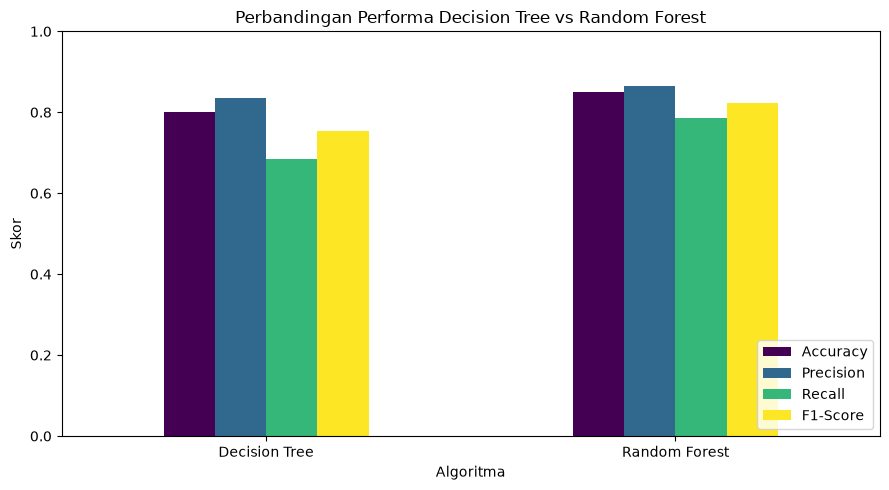

In [55]:
comparison_df.set_index('Algoritma')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(9, 5), colormap='viridis'
)
plt.title('Perbandingan Performa Decision Tree vs Random Forest')
plt.ylabel('Skor')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('perbandingan_metrik.png', dpi=150, bbox_inches='tight')   # tambahan ini
plt.show()

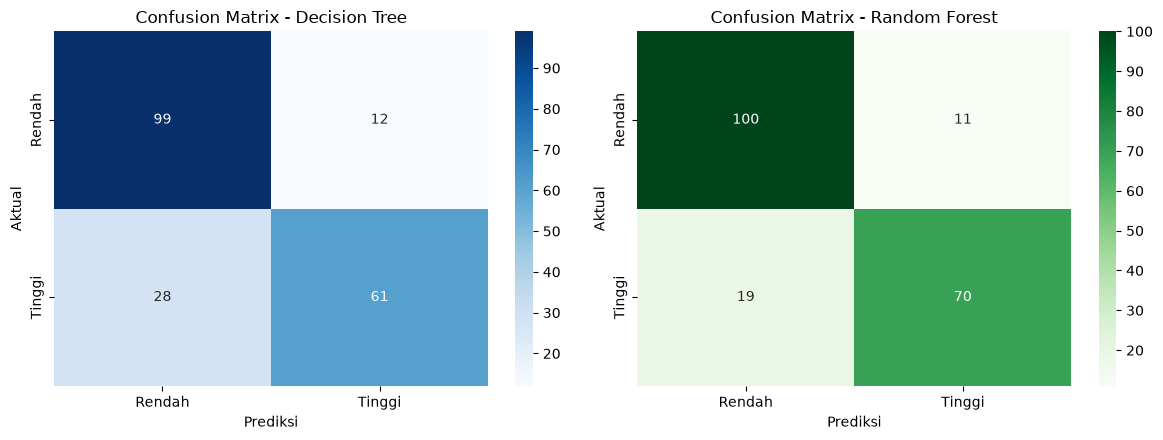

In [56]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rendah', 'Tinggi'], yticklabels=['Rendah', 'Tinggi'])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Rendah', 'Tinggi'], yticklabels=['Rendah', 'Tinggi'])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight') 

## 12. Pengujian Overfitting

Untuk memvalidasi dugaan bahwa Decision Tree lebih rentan overfitting 
dibandingkan Random Forest, dilakukan pengujian dengan membandingkan 
akurasi model pada data latih (train) dan data uji (test). Selisih yang 
besar antara akurasi latih dan uji mengindikasikan model mengalami 
overfitting (menghafal data latih, namun tidak dapat generalisasi dengan 
baik pada data baru).

In [57]:
# Akurasi pada data latih vs data uji
dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc = accuracy_score(y_test, y_pred_dt)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, y_pred_rf)

overfit_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Akurasi Train': [dt_train_acc, rf_train_acc],
    'Akurasi Test': [dt_test_acc, rf_test_acc],
    'Selisih (Gap)': [dt_train_acc - dt_test_acc, rf_train_acc - rf_test_acc]
})

overfit_df

,Model,Akurasi Train,Akurasi Test,Selisih (Gap)
0,Decision Tree,0.86125,0.80,0.06125
1,Random Forest,0.88625,0.85,0.03625


## 13. Visualisasi Learning Curve

Learning curve menampilkan perbandingan skor akurasi pada data latih dan 
data validasi seiring bertambahnya jumlah data yang digunakan untuk 
melatih model. Pola grafik dapat mengindikasikan kondisi model:
- **Overfitting**: skor latih tinggi, namun skor validasi jauh lebih rendah 
  dan kesenjangan (gap) antara keduanya besar.
- **Underfitting**: skor latih dan validasi sama-sama rendah.
- **Good fit**: skor latih dan validasi saling mendekati dengan nilai yang 
  cukup tinggi.

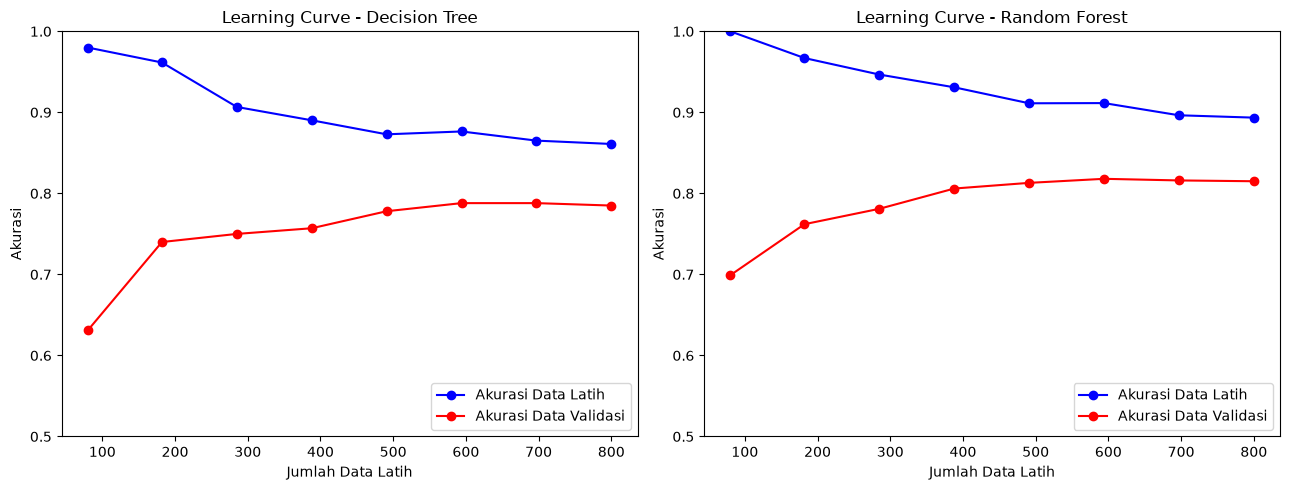

In [58]:
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(model, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Akurasi Data Latih')
    ax.plot(train_sizes, val_mean, 'o-', color='red', label='Akurasi Data Validasi')
    ax.set_title(title)
    ax.set_xlabel('Jumlah Data Latih')
    ax.set_ylabel('Akurasi')
    ax.legend(loc='lower right')
    ax.set_ylim(0.5, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_learning_curve(DecisionTreeClassifier(max_depth=5, random_state=42), X, y, 'Learning Curve - Decision Tree', axes[0])
plot_learning_curve(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42), X, y, 'Learning Curve - Random Forest', axes[1])
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Analisis Learning Curve dan Koreksi Kesimpulan

Berdasarkan tabel pengujian sebelumnya (Cell 25), Decision Tree memiliki 
gap akurasi train-test sebesar 6.1% (86.1% vs 80%), sedangkan Random Forest 
memiliki gap yang lebih kecil yaitu 3.6% (88.6% vs 85%). Learning curve pada 
Gambar di atas juga menguatkan temuan ini: kedua model sama-sama mengalami 
overfitting yang lebih besar saat data latih sedikit (gap 30-35% pada 
n=80), namun gap tersebut menyempit signifikan seiring bertambahnya data, 
dengan Random Forest secara konsisten menunjukkan gap yang lebih kecil 
dibandingkan Decision Tree pada seluruh ukuran data.

Temuan ini konsisten dengan karakteristik teoritis Random Forest sebagai 
model ensemble yang lebih tahan terhadap overfitting dibandingkan pohon 
keputusan tunggal, sekaligus menjelaskan mengapa Random Forest memperoleh 
akurasi validasi yang lebih tinggi secara konsisten (81.5% vs 78.5% pada 
data penuh).

Kedua kurva juga menunjukkan tren konvergen (gap terus menyempit), yang 
mengindikasikan bahwa penambahan jumlah data lebih lanjut berpotensi 
meningkatkan performa kedua model, terutama Decision Tree yang gap-nya 
masih sedikit lebih lebar.

## 14. Analisis dan Pembahasan Hasil

**Perbandingan Metrik Evaluasi**

Berdasarkan bar chart perbandingan performa, **Random Forest secara konsisten 
unggul di keempat metrik** dibandingkan Decision Tree:
- Accuracy: 85% (Random Forest) vs 80% (Decision Tree)
- Precision: 86.4% vs 83.6%
- Recall: 78.7% vs 68.5%
- F1-Score: 82.4% vs 75.3%

Peningkatan paling signifikan terlihat pada metrik **Recall**, yang naik 
sekitar 10 poin persentase. Hal ini menunjukkan Random Forest jauh lebih 
baik dalam mengenali film dengan rating tinggi, yang merupakan kelas 
minoritas (44.5% dari total data).

**Analisis Confusion Matrix (Error Analysis)**

| Model | True Negative | False Positive | False Negative | True Positive |
|---|---|---|---|---|
| Decision Tree | 99 | 12 | 28 | 61 |
| Random Forest | 100 | 11 | 19 | 70 |

Kesalahan klasifikasi terbesar pada kedua model terjadi pada **False 
Negative** (film dengan rating tinggi yang salah diprediksi sebagai rating 
rendah): Decision Tree melakukan 28 kesalahan jenis ini, sementara Random 
Forest berhasil menekannya menjadi 19 kesalahan. Ini mengindikasikan bahwa 
Decision Tree cenderung *underfit* dalam mengenali pola kompleks yang 
membedakan film berating tinggi, kemungkinan karena struktur pohon tunggal 
lebih mudah terjebak pada aturan pemisahan yang terlalu sederhana. Random 
Forest, dengan menggabungkan 200 pohon melalui mekanisme voting, mampu 
menangkap pola yang lebih beragam sehingga mengurangi bias tersebut.

Kedua model relatif konsisten dalam memprediksi kelas "Rendah" (False 
Positive rendah, 11-12 kasus), yang berarti keduanya jarang salah menilai 
film berating rendah sebagai berating tinggi.

**Kesimpulan Sementara**

Random Forest terbukti menjadi model yang lebih unggul dan stabil untuk 
kasus klasifikasi rating film pada dataset ini, sejalan dengan karakteristik 
algoritma ensemble yang secara teoritis lebih tahan terhadap overfitting 
dibandingkan pohon keputusan tunggal.

## 15. Feature Importance (Random Forest)

Salah satu kelebihan Random Forest adalah kemampuannya menghitung tingkat 
kepentingan (importance) tiap fitur terhadap hasil prediksi. Analisis ini 
berguna untuk memahami faktor apa saja yang paling memengaruhi tinggi 
rendahnya rating sebuah film.

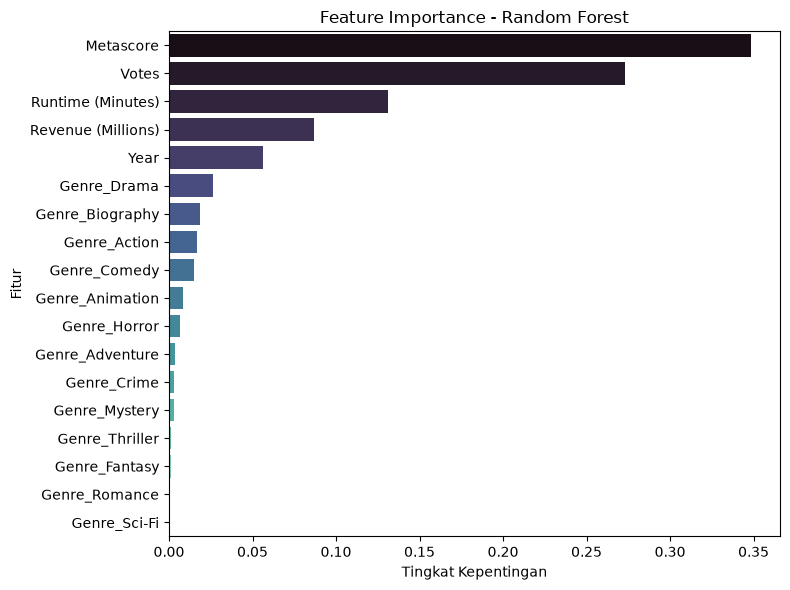

,Fitur,Importance
4,Metascore,0.348395
2,Votes,0.272976
1,Runtime (Minutes),0.130965
3,Revenue (Millions),0.086538
0,Year,0.056275
11,Genre_Drama,0.026469
8,Genre_Biography,0.018737
5,Genre_Action,0.016796
9,Genre_Comedy,0.014717
7,Genre_Animation,0.008385


In [59]:
# Ambil feature importance dari model Random Forest
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Fitur', data=importance_df, hue='Fitur', palette='mako', legend=False)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Tingkat Kepentingan')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importance_df

## 16. Analisis Feature Importance

Berdasarkan grafik feature importance, dapat diamati bahwa **5 fitur 
numerik mendominasi kontribusi prediksi**, dengan total kontribusi 
mencapai sekitar 89.5% dari keseluruhan model:

1. **Metascore (34.8%)** — fitur paling berpengaruh. Hal ini masuk akal 
   karena Metascore merupakan skor gabungan dari para kritikus film, yang 
   secara alami berkorelasi kuat dengan rating IMDB (penilaian audiens 
   umum), meskipun keduanya berasal dari sumber penilai yang berbeda.
2. **Votes (27.3%)** — jumlah voting yang tinggi umumnya berasal dari film 
   populer/berkualitas yang ditonton banyak orang, sehingga cenderung 
   berkorelasi dengan rating yang lebih stabil dan tinggi.
3. **Runtime (13.1%)** — durasi film turut memengaruhi, kemungkinan film 
   dengan durasi lebih panjang cenderung merupakan film drama/epik yang 
   digarap lebih serius.
4. **Revenue (8.7%)** dan **Year (5.6%)** memberikan kontribusi lebih kecil 
   namun tetap relevan.

Sebaliknya, **fitur genre (one-hot encoding) memberikan kontribusi yang 
sangat kecil secara individual** (di bawah 3% masing-masing, total gabungan 
~10.5%), menunjukkan bahwa genre film bukan merupakan penentu utama tinggi 
rendahnya rating — kualitas produksi (tercermin dari Metascore dan Votes) 
jauh lebih dominan.

**Catatan penting:** dominasi Metascore perlu dicermati sebagai potensi 
keterbatasan model, karena skor ini pada dasarnya adalah bentuk lain dari 
penilaian kualitas film (mirip dengan target Rating), sehingga model 
sebagian besar "belajar" dari korelasi antar-skor penilaian, bukan murni 
dari atribut objektif film seperti genre atau durasi.

## 17. Kesimpulan

Penelitian ini membangun model klasifikasi untuk memprediksi kategori 
rating film (Tinggi/Rendah) menggunakan dataset IMDB Movie Data (2006–2016) 
yang berisi 1000 film, dengan membandingkan dua algoritma Machine Learning: 
**Decision Tree** dan **Random Forest**.

**Ringkasan hasil:**
- Random Forest menghasilkan performa lebih baik pada seluruh metrik 
  evaluasi dibandingkan Decision Tree, dengan Accuracy 85% (vs 80%), 
  Precision 86.4% (vs 83.6%), Recall 78.7% (vs 68.5%), dan F1-Score 82.4% 
  (vs 75.3%).
- Analisis learning curve menunjukkan kedua model mengalami overfitting 
  ringan pada kondisi data sedikit, namun gap tersebut menyempit seiring 
  bertambahnya data dan relatif setara antara kedua model pada data penuh 
  (~7.5-8%). Keunggulan Random Forest terletak pada kemampuan generalisasi 
  yang lebih baik secara absolut, bukan karena bebas dari overfitting.
- Feature importance mengungkapkan bahwa **Metascore** dan **Votes** 
  merupakan dua faktor paling dominan dalam memprediksi rating film, 
  sementara atribut genre memberikan kontribusi yang relatif kecil.

**Saran untuk penelitian selanjutnya:**
1. Melakukan hyperparameter tuning (misalnya menggunakan GridSearchCV) 
   untuk mengoptimalkan performa kedua model lebih lanjut.
2. Menguji pengaruh fitur Metascore secara terpisah, mengingat sifatnya 
   yang berpotensi terlalu berkorelasi dengan target (Rating).
3. Menambahkan fitur lain seperti popularitas sutradara/aktor atau analisis 
   sentimen dari kolom Description untuk memperkaya representasi data.
4. Memperluas dataset dengan menyertakan film di luar rentang tahun 
   2006–2016 untuk meningkatkan generalisasi model.